# Transform Crowd4U TAR table data to toolkit format 
**（Crowd4UのTARテーブルデータをツールキットの形式に変換する）**

This notebook demonstrates the process of converting Crowd4U TAR table data for the aggregation toolkit.

このノートブックではCrowd4UのTARテーブルデータを集約ツールキットの形式に変換する方法を説明します。

## 1. Starting the notebook (ノートブックの起動）

1. Open a terminal with `docker` access and go to the toolkit folder. / dockerコマンドが利用できるターミナルで、ツールキットのフォルダに移動します。
2. Run the following command to start the container. / 次のコマンドでコンテナを起動します。
```sh
docker compose up -d
```
3. Run the following command and copy the `token` value. / 次のコマンドを実行し、`token`の値をコピーします。
```sh
docker exec crowd4u-aggregation-toolkit jupyter server list

Currently running servers:
http://90d6fd7b33a7:8888/?token=************* :: /toolkit_root
```
4. Access http://localhost:8008/ and enter the `token`. / http://localhost:8008/ にアクセスし、`token`を入力します。
5. Open `transform_tar_table.ipynb` (this file). / `transform_tar_table.ipynb` (このファイル）を開いてください。

## 2. Placing the TAR table data (TARテーブルデータの設置)

Place the TAR table data from Crowd4U into the `tar_tables/` directory. This notebook uses `tar_tables/sample_tar_table.csv` to demonstrate the processing steps.

Crowd4UからダウンロードしたTARテーブルデータは`tar_tables/`フォルダに保存してください。このノートブックでは`tar_tables/sample_tar_table.csv`を例に処理を進めます。

The sample data illustrates a 3-class classification problem, involving humans and three distinct AI workers.

サンプルデータ以下のような3クラス分類問題を例にしており、人間の他に３つのAIワーカが参加しています。

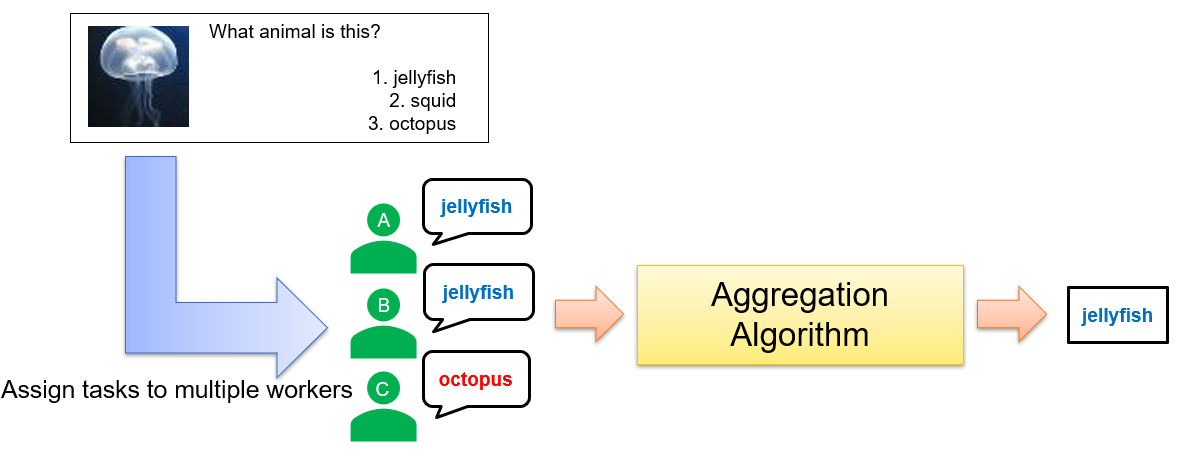



## 3. Data Loading and Processing (データのロードと加工)
To run the code in a cell, click the ▶ button at the top or press Control (Command) + Enter.

セルのコードを実行するには、上部の▶ボタンを押すか、Control (Command) + Enter を押します。

**The format of the TAR table varies significantly depending on the task assignment code, so the code provided here may not work as-is. Please modify the code as necessary.**

**TARテーブルの形式はタスクアサインメントのコードによって大きく変わるため、ここにあるコードの通りに動かないことがあります。必要に応じてコードを変更してください。**

In [46]:
import json
import pandas as pd

In [47]:
# Please change this to your own file as necessary.
# 必要に応じて自身のファイルに変更してください。

df = pd.read_csv("tar_tables/sample_tar_table.csv")

In [48]:
df.head()

,id,run_id,dataitem_id,qualified_worker_type,assigned_worker_id,result,qualified_at,assigned_at,completed_at,created_at,updated_at
0,1,02a57508-b0ba-40e8-8ae7-876088428709,question_1,human,human1,{'answer':'jellyfish'},NaN,2025-04-16 18:55:53,2025-04-16 18:57:45,2025-04-16 15:23:23,2025-04-16 18:57:44
1,2,02a57508-b0ba-40e8-8ae7-876088428709,question_1,human,human2,{'answer':'squid'},NaN,2025-04-16 18:56:01,2025-04-16 18:58:10,2025-04-16 15:23:23,2025-04-16 18:58:09
2,3,02a57508-b0ba-40e8-8ae7-876088428709,question_1,human,human3,{'answer':'jellyfish'},NaN,2025-04-16 18:56:10,2025-04-16 18:59:20,2025-04-16 15:23:23,2025-04-16 18:59:19
3,4,02a57508-b0ba-40e8-8ae7-876088428709,question_2,human,human1,{'answer':'squid'},NaN,2025-04-16 18:57:00,2025-04-16 19:00:00,2025-04-16 15:23:23,2025-04-16 19:00:00
4,5,02a57508-b0ba-40e8-8ae7-876088428709,question_2,human,human2,{'answer':'jellyfish'},NaN,2025-04-16 18:57:30,2025-04-16 19:01:00,2025-04-16 15:23:23,2025-04-16 19:01:00


In [49]:
# task,worker,label,そして、ワーカの種類（人間/AI）を示すカラムのみを取り出します。
# Select only the task, worker, label, and worker type (Human/AI) columns.
df = df[["dataitem_id", "qualified_worker_type", "assigned_worker_id", "result"]]

In [50]:
df.head()

,dataitem_id,qualified_worker_type,assigned_worker_id,result
0,question_1,human,human1,{'answer':'jellyfish'}
1,question_1,human,human2,{'answer':'squid'}
2,question_1,human,human3,{'answer':'jellyfish'}
3,question_2,human,human1,{'answer':'squid'}
4,question_2,human,human2,{'answer':'jellyfish'}


In Crowd4U, the result column is formatted as JSON, allowing requesters to freely configure multiple key-value pairs. In this notebook, we will use the value of the `answer` key as the label.

Crowd4Uではresult列の中身をJSON形式とし依頼者の設定で自由にkey-valueのペアを複数を設定できます。今回は`answer`キーの値を`label`として扱います。

Note: In Crowd4U, single quotes are used in the result column instead of double quotes. It is necessary to convert these back to double quotes.

注：Crowd4Uではダブルクオーテーションではなくシングルクオーテーションが`result`に用いられており、これをダブルクオーテーションに戻す必要があります。

In [51]:
df["label"] = df["result"].apply(lambda x: json.loads(x.replace("\'", "\""))["answer"])

In [52]:
# Rename Columns / カラム名の変更
df = df.rename({"dataitem_id":"task", "assigned_worker_id":"worker"}, axis=1)

In [53]:
df

,task,qualified_worker_type,worker,result,label
0,question_1,human,human1,{'answer':'jellyfish'},jellyfish
1,question_1,human,human2,{'answer':'squid'},squid
2,question_1,human,human3,{'answer':'jellyfish'},jellyfish
3,question_2,human,human1,{'answer':'squid'},squid
4,question_2,human,human2,{'answer':'jellyfish'},jellyfish
5,question_2,human,human3,{'answer':'squid'},squid
6,question_3,human,human1,{'answer':'octopus'},octopus
7,question_3,human,human2,{'answer':'jellyfish'},jellyfish
8,question_3,human,human3,{'answer':'octopus'},octopus
9,question_1,ai,GPT-4,{'answer':'jellyfish'},jellyfish


In [54]:
# Split the data into human and AI datasets.
# 人間データとAIデータに分割します
human_data = df[df["qualified_worker_type"]=="human"][["task","worker","label"]]
ai_data = df[df["qualified_worker_type"]=="ai"][["task","worker","label"]]

In [55]:
human_data

,task,worker,label
0,question_1,human1,jellyfish
1,question_1,human2,squid
2,question_1,human3,jellyfish
3,question_2,human1,squid
4,question_2,human2,jellyfish
5,question_2,human3,squid
6,question_3,human1,octopus
7,question_3,human2,jellyfish
8,question_3,human3,octopus


In [56]:
ai_data

,task,worker,label
9,question_1,GPT-4,jellyfish
10,question_2,GPT-4,squid
11,question_3,GPT-4,octopus
12,question_1,Claude,jellyfish
13,question_2,Claude,squid
14,question_3,Claude,squid
15,question_1,original_model,squid
16,question_2,original_model,jellyfish
17,question_3,original_model,octopus


In [57]:
# Save the data. Please change the filename as necessary.
# データを保存します。必要に応じてファイル名を変更してください。
human_data.to_csv("datasets/sample_human_from_tar_table.csv", index=False)
ai_data.to_csv("datasets/sample_ai_from_tar_table.csv", index=False)

Finally, save the label list data as a JSON file.

最後に、ラベル一覧データをJSONで保存します。

In [58]:
labels = ["jellyfish", "squid", "octopus"]
with open("datasets/sample_labels_from_tar_table.json", "w") as f:
    json.dump(labels, f)